In [2]:
import os

In [3]:
%pwd

'c:\\Users\\User\\Desktop\\DS\\Kidney_cancer\\research'

In [4]:
os.chdir('..')

In [5]:
%pwd

'c:\\Users\\User\\Desktop\\DS\\Kidney_cancer'

In [6]:
from dataclasses import dataclass
from pathlib import Path

@dataclass(frozen=True)
class TrainingConfig:
    root_dir: Path
    trained_model_path: Path
    updated_base_model_path: Path
    training_data: Path
    params_epoch: int
    params_batch_size: int
    params_is_augmentation: bool
    params_image_size: list
    params_learning_rate: float

In [7]:
from kidney_cancer.constants import  CONFIG_FILE_PATH, PARAMS_FILE_PATH
from kidney_cancer.utils.common import read_yaml, create_directories
import torch
from torch import nn

In [12]:
class ConfigurationManager:
    def __init__(
            self,
            config_filepath = CONFIG_FILE_PATH,
            params_filepath = PARAMS_FILE_PATH):
        
        self.config = read_yaml(config_filepath)
        self.params = read_yaml(params_filepath)

        create_directories([self.config.artifacts_root])
    
    def get_training_config(self) -> TrainingConfig:
        training = self.config.model_training
        base_model = self.config.base_model
        params = self.params
        data_path = os.path.join(self.config.data_ingestion.unzip_dir,"Kidney_dataset")
        create_directories([Path(training.root_dir)])

        training_config = TrainingConfig(
            root_dir=Path(training.root_dir),
            trained_model_path=Path(training.trained_model_path),
            updated_base_model_path=Path(base_model.updated_base_model_path),
            training_data=Path(data_path),
            params_epoch=params.EPOCHS,
            params_batch_size=params.BATCH_SIZE,
            params_is_augmentation=params.AUGMENTATION,
            params_image_size=params.IMAGE_SIZE,
            params_learning_rate=params.LEARNING_RATE
        )

        return training_config


In [9]:
import time
import os
from PIL import Image
from kidney_cancer import logger
from kidney_cancer.config.configuration import ConfigurationManager
import urllib.request as request
from zipfile import ZipFile
import torch
from torch import nn
import torchvision
from torchvision.transforms import v2
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

In [ ]:
class ModelTraining:
    def __init__(self, config: TrainingConfig):
        self.config = config
        self.device = "cuda" if torch.cuda.is_available() else "cpu"
    
    def get_base_model(self):
        self.model = torch.load(
            self.config.updated_base_model_path,
            weights_only=False
        )
    
    def train_val_loader(self):
        self.transforms = v2.Compose([
            v2.ToImage(),
            v2.Resize(size=[224,224]),
            v2.ToDtype(dtype=torch.float32,scale=True)])

        self.train_data = ImageFolder(
            root=self.config.training_data / "Train",
            transform=self.transforms)

        self.val_data = ImageFolder(
            root=self.config.training_data / "Val",
            transform=self.transforms)
        
        if self.config.params_is_augmentation:
            pass
            
        self.train_dataloader = DataLoader(self.train_data,
                                           batch_size=self.config.params_batch_size,
                                           shuffle=True)
        
        self.val_dataloader = DataLoader(self.val_data,
                                          batch_size=self.config.params_batch_size,
                                          shuffle=True)
    
    @staticmethod
    def save_model(path: Path, model: torchvision.models):
        model.save(path)

    def train(self):
        self.loss_fn = nn.CrossEntropyLoss()
        self.optim = torch.optim.Adam(params=self.model.parameters(),lr=self.config.params_learning_rate)
        self.model = self.model.to(self.device)
        for epoch in range(self.config.params_epoch):

            self.model.train()

            train_loss, train_acc = 0, 0
            logger.info("Training Started")
            for batch, (X, y) in enumerate(self.train_dataloader):
                
                X, y = X.to(self.device), y.to(self.device)

                y_pred = self.model(X)

                loss = self.loss_fn(y_pred, y)
                train_loss += loss.item() 

                self.optim.zero_grad()

                loss.backward()

                self.optim.step()

                y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
                train_acc += (y_pred_class == y).sum().item()/len(y_pred)

                train_loss = train_loss / len(self.train_dataloader)
                train_acc = train_acc / len(self.train_dataloader)

                if batch + 1 %10 == 0:
                    logger.info("Training loss: %s | Train Accuracy: %s",train_loss,train_acc)
                
            self.model.eval() 

            test_loss, test_acc = 0, 0

            with torch.inference_mode():
                for batch, (X_val, y_val) in enumerate(self.val_dataloader):
                    X_val, y_val = X_val.to(self.device), y_val.to(self.device)

                    test_pred_logits = self.model(X_val)

                    loss = self.loss_fn(test_pred_logits, y_val)
                    test_loss += loss.item()

                    test_pred_labels = test_pred_logits.argmax(dim=1)

                    test_acc += ((test_pred_labels == y_val).sum().item()/len(test_pred_labels))
                    

            test_loss = test_loss / len(self.val_dataloader)
            test_acc = test_acc / len(self.val_dataloader)
            logger.info("Training Loss: %s | Train Accuracy: %s | Test Loss: %s | Test Accuracy",train_loss,train_acc,test_loss,test_acc)
            
            return train_loss, train_acc, test_loss, test_acc

In [35]:
try:
    config = ConfigurationManager()
    training_config = config.get_training_config()
    training = ModelTraining(config=training_config)
    training.get_base_model()
    training.train_val_loader()
    training.train()

except Exception as e:
    raise e

[2025-07-29 10:21:09,102: INFO: common: yaml file: config\config.yaml loaded successfully]
[2025-07-29 10:21:09,105: INFO: common: yaml file: params.yaml loaded successfully]
[2025-07-29 10:21:09,112: INFO: common: created directory at: artifacts]
[2025-07-29 10:21:09,115: INFO: common: created directory at: artifacts\model_training]
[2025-07-29 10:21:10,101: INFO: 681561276: Training Started]
[2025-07-29 10:21:17,187: INFO: 681561276: Training loss: 0.0030834927309027925 | Train Accuracy: 0.0027292576419213972]


KeyboardInterrupt: 

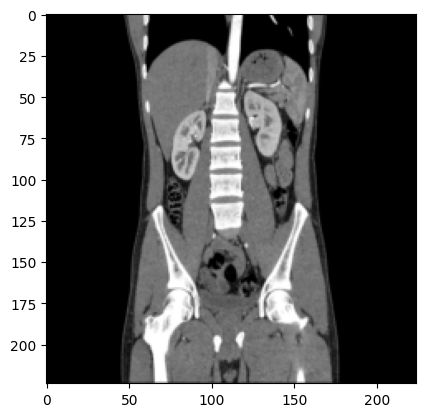

In [ ]:
from torchvision.transforms import v2
from PIL import Image
import torch

img = Image.open(r"C:\Users\User\Desktop\DS\Kidney_cancer\artifacts\data_ingestion\Kidney_dataset\Train\Normal\Normal- (2282).jpg")

import matplotlib.pyplot as plt
plt.imshow(torch.permute(transform(img),dims=(1,2,0)))